In [4]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict
import string

In [3]:
model = ChatOllama( model="llama3.2:3b",
    temperature=0)

In [5]:
class BlogState(TypedDict):
    topic:string
    outline:string
    content:string

In [ ]:
def generate_outline(state:BlogState)->BlogState:
    topic = state['topic']
    prompt = f'generate an outline for a blog , topic of the blog is : {topic}'
    state['outline'] = model.invoke(prompt).content
    return state

In [7]:
def generate_content(state:BlogState)->BlogState:
    topic = state['topic']
    outline = state['outline']
    prompt = f"make content for the topic {topic} , follow the outline {outline}"
    state['content'] = model.invoke(prompt).content
    return state

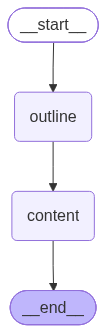

In [9]:
graph = StateGraph(BlogState)
graph.add_node('outline',generate_outline)
graph.add_node('content',generate_content)
graph.add_edge(START,'outline')
graph.add_edge('outline','content')
graph.add_edge('content',END)
workflow = graph.compile()
workflow

In [11]:
final_state = workflow.invoke({'topic':'Risk of AI'})

In [14]:
print(final_state['content'])

Here's a comprehensive blog on the topic "Risk of AI" based on the provided outline:

**The Risk of AI: A Growing Concern**

Artificial Intelligence (AI) has become an integral part of our lives, transforming the way we live, work, and interact with each other. From virtual assistants to self-driving cars, AI has the potential to bring about significant benefits and improve our daily lives. However, as AI continues to advance and become more pervasive, it also poses several risks that need to be addressed. In this blog, we will explore the types of risks associated with AI, their consequences, and potential solutions to mitigate these risks.

**Types of Risks Associated with AI**

1. **Job Displacement**: AI has the potential to automate jobs, leading to widespread unemployment. As machines and algorithms take over tasks that were previously performed by humans, many jobs may become obsolete. This could lead to economic instability and inequality, as those who are not equipped with the